# Introduction to Machine Learning for Neuroscience
# Final Project
**05/03/2025** 

**Gilad Shilo ID: 318337136**

**Iakov Odesser ID: 209860288**

## EDA

We begin by loading the EmoSet dataset from JSON and flattening the nested annotations into a pandas DataFrame. 


In [28]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [29]:
file_path = 'emoset_challenge_1000_augmented.json'
with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.json_normalize(data, sep='_')  # flatten nested annotations

print("--- Data Overview ---")
df.info()
print("\n--- First 5 Rows ---")
print(df.head())


--- Data Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   image_name                     1000 non-null   object 
 1   description                    1000 non-null   object 
 2   embedding                      1000 non-null   object 
 3   viewer_feelings                1000 non-null   object 
 4   description_embedding          1000 non-null   object 
 5   viewer_feelings_embedding      1000 non-null   object 
 6   annotations_image_id           1000 non-null   object 
 7   annotations_emotion            1000 non-null   object 
 8   annotations_brightness         999 non-null    float64
 9   annotations_colorfulness       976 non-null    float64
 10  annotations_facial_expression  112 non-null    object 
 11  annotations_object             513 non-null    object 
 12  annotations_human_action   

It seems that image_name and annotations_image_id are the same. We'll make sure that they are indeeed 100% identical and drop the latter if the assumption holds 

In [30]:
df = df.drop(columns=['annotations_image_id']) if (df['image_name'].str.replace('.jpg', '', regex=False) == df['annotations_image_id']).all() else df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   image_name                     1000 non-null   object 
 1   description                    1000 non-null   object 
 2   embedding                      1000 non-null   object 
 3   viewer_feelings                1000 non-null   object 
 4   description_embedding          1000 non-null   object 
 5   viewer_feelings_embedding      1000 non-null   object 
 6   annotations_emotion            1000 non-null   object 
 7   annotations_brightness         999 non-null    float64
 8   annotations_colorfulness       976 non-null    float64
 9   annotations_facial_expression  112 non-null    object 
 10  annotations_object             513 non-null    object 
 11  annotations_human_action       114 non-null    object 
 12  annotations_scene              212 non-null    ob

We now proceed to explore the descriptives: 

In [31]:
print("\n--- Emotion Distribution ---")
emotion_counts = df['annotations_emotion'].value_counts()
print(emotion_counts)

print("\n--- Summary Statistics for Visual Features ---")
print(df[['annotations_brightness', 'annotations_colorfulness']].describe())



--- Emotion Distribution ---
annotations_emotion
anger          125
excitement     125
disgust        125
amusement      125
awe            125
contentment    125
sadness        125
fear           125
Name: count, dtype: int64

--- Summary Statistics for Visual Features ---
       annotations_brightness  annotations_colorfulness
count              999.000000                976.000000
mean                 0.483884                  0.493545
std                  0.151183                  0.195302
min                  0.000000                  0.000000
25%                  0.400000                  0.400000
50%                  0.500000                  0.500000
75%                  0.600000                  0.600000
max                  0.900000                  1.000000


Evidently, we have a uniform distribution. The columns of interest almost lack NaN values, and we'll handle them later on. We now proceed to plotting: 

C:\Users\odis\AppData\Local\Temp\ipykernel_60220\4216679020.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=axes[0], data=df, x='annotations_emotion', y='annotations_brightness', palette='viridis')
C:\Users\odis\AppData\Local\Temp\ipykernel_60220\4216679020.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=axes[1], data=df, x='annotations_emotion', y='annotations_colorfulness', palette='viridis')


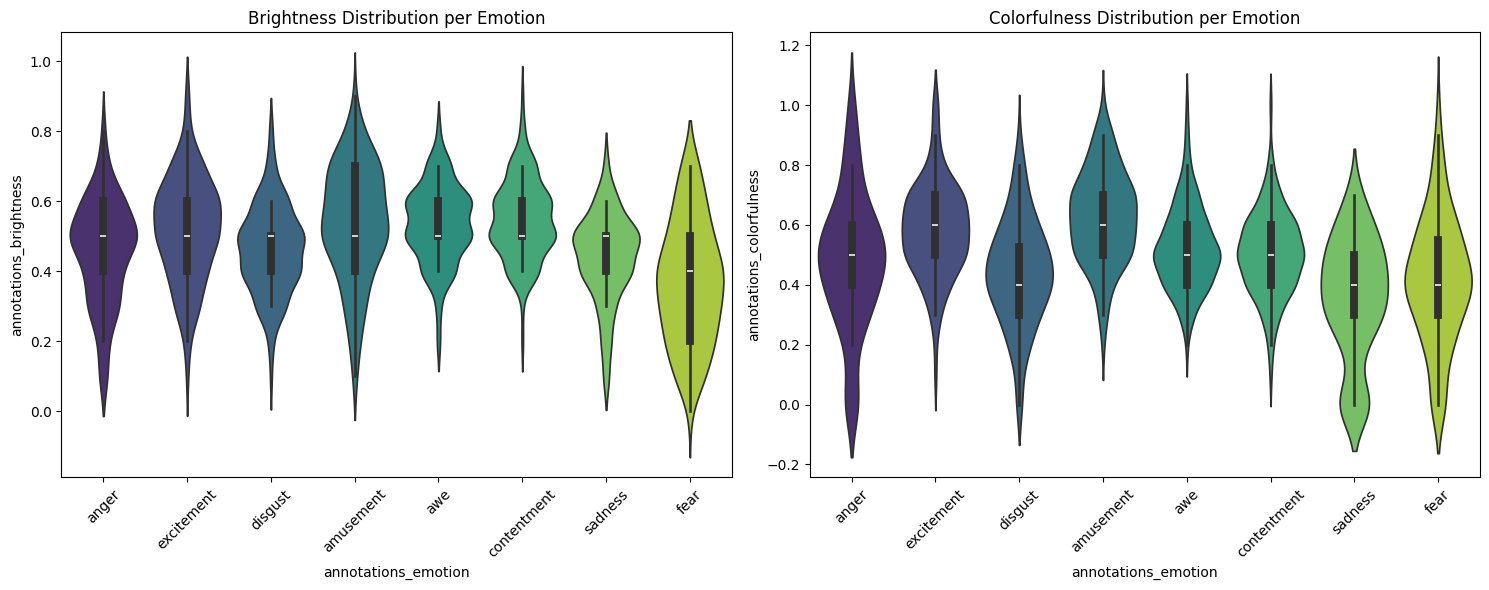

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))  # brightness & colorfulness per emotion
sns.violinplot(ax=axes[0], data=df, x='annotations_emotion', y='annotations_brightness', palette='viridis')
axes[0].set_title('Brightness Distribution per Emotion')
axes[0].tick_params(axis='x', rotation=45)

sns.violinplot(ax=axes[1], data=df, x='annotations_emotion', y='annotations_colorfulness', palette='viridis')
axes[1].set_title('Colorfulness Distribution per Emotion')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

From the violin plots, we can observe:

*Brightness:* Fear and sadness are associated with darker images, while amusement and excitement tend toward brighter imagery, suggesting a relationship between image brightness and emotional valence.

*Colorfulness:* Sadness exhibits notably lower colorfulness compared to other emotions, while excitement and amusement show higher saturation, indicating that positive high-arousal emotions correlate with more vibrant imagery.